# How to get started with the Wikimedia data

The [Wikipedia Structured Contents](https://www.kaggle.com/datasets/wikimedia-foundation/wikipedia-structured-contents) dataset on Kaggle contains all articles of the English and French language editions of Wikipedia, pre-parsed and outputted as structured JSON files with a consistent schema. Each JSON line holds the content of one full Wikipedia article stripped of extra markdown and non-prose sections (references, etc.).

The data is divided into multiple large `.jsonl` files. Here we will explore just one of those files: `./wikipedia-structured-contents/enwiki_namespace_0/enwiki_namespace_0_0.jsonl`.

## Initial Setup


In [1]:
!pip install -q wordcloud textblob

In [2]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
from tqdm import tqdm
from datetime import datetime
import re
from wordcloud import WordCloud
import networkx as nx
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set(style="whitegrid")

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

## Load Data

In [3]:
def read_jsonl(file_path, max_records=None):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f)):
            if max_records and i >= max_records:
                break
            data.append(json.loads(line))
    return data

In [4]:
import kagglehub
file_path = kagglehub.dataset_download("wikimedia-foundation/wikipedia-structured-contents",path="enwiki_namespace_0/enwiki_namespace_0_0.jsonl")
data = read_jsonl(file_path)
print(f"Successfully loaded {len(data)} records")

309509it [01:18, 3948.18it/s]

Successfully loaded 309509 records


## Preview Data

In [5]:
df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print("\nColumns in the dataset:")
for col in df.columns:
    
    print(f"- {col}")

Dataset shape: (309509, 17)

Columns in the dataset:
- name
- identifier
- version
- event
- url
- date_created
- date_modified
- is_part_of
- in_language
- license
- description
- sections
- abstract
- main_entity
- additional_entities
- infoboxes
- image


In [6]:
print("\nSample data:")
display(df.head())


Sample data:


,name,identifier,version,event,url,date_created,date_modified,is_part_of,in_language,license,description,sections,abstract,main_entity,additional_entities,infoboxes,image
0,Not Again SU,76716259,"{'identifier': 1220413474, 'comment': 'Added #...",{'identifier': 'fa3cae5b-8707-4f55-9fab-5baa4c...,https://en.wikipedia.org/wiki/Not_Again_SU,2024-04-23T16:50:32Z,2024-04-23T16:53:55Z,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,"Student organization in Syracuse, New York","[{'type': 'section', 'name': 'Abstract'}, {'ty...",NaN,NaN,NaN,NaN,NaN
1,Mike Ross (Suits),76727681,"{'identifier': 1220574416, 'comment': 'Request...",{'identifier': '22366970-ddf7-43dc-8cec-941de1...,https://en.wikipedia.org/wiki/Mike_Ross_(Suits),2024-04-24T17:12:05Z,2024-04-24T17:14:10Z,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,An American Legal drama series from 2011-2019,"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT List of Suits characters#Mike Ross,"{'identifier': 'Q125388612', 'url': 'https://w...","[{'identifier': 'Q125388612', 'url': 'https://...",NaN,NaN
2,Second Polish republic,76744378,"{'identifier': 1220875620, 'comment': '[[WP:AE...",{'identifier': '552624d6-5c55-45ef-a8e3-945335...,https://en.wikipedia.org/wiki/Second_Polish_re...,2024-04-26T13:30:10Z,2024-04-26T13:30:10Z,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Country in Central and Eastern Europe (1918–1939),"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT #Second Polish Republic,NaN,NaN,NaN,NaN
3,Left-to-right script,76735997,"{'identifier': 1220716997, 'comment': 'create ...",{'identifier': 'aae6c4ee-bf95-4dc0-942d-5eea53...,https://en.wikipedia.org/wiki/Left-to-right_sc...,2024-04-25T13:58:39Z,2024-04-25T13:58:39Z,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,Convention of symbols representing language,"[{'type': 'section', 'name': 'Abstract', 'has_...",REDIRECT Writing system#Directionality,NaN,NaN,NaN,NaN
4,1442 in France,58128987,"{'identifier': 1145356533, 'comment': 'Alter: ...",{'identifier': 'c4526432-0a4a-42ed-8ef7-54827c...,https://en.wikipedia.org/wiki/1442_in_France,NaN,2023-03-18T18:38:51Z,"{'identifier': 'enwiki', 'url': 'https://en.wi...",{'identifier': 'en'},[{'name': 'Creative Commons Attribution-ShareA...,List of events in the year 1442,"[{'type': 'section', 'name': 'Abstract', 'has_...",Events from the year 1442 in France,"{'identifier': 'Q56292328', 'url': 'https://ww...","[{'identifier': 'Q56292328', 'url': 'https://w...","[{'type': 'infobox', 'name': 'Year in France h...",NaN


In [7]:
# Analysis for name field
if 'name' in df.columns:
    
    # Word frequency in names
    all_names = ' '.join(df['name'].dropna().astype(str))
    words = re.findall(r'\b\w+\b', all_names.lower())
    stop_words = set(stopwords.words('english'))

## Explore Descriptions

Most common words in descriptions:
  term: 23534
  topics: 23388
  referred: 23387
  species: 22338
  american: 19096
  season: 14926
  football: 13288
  village: 12284
  united: 9875
  states: 9289
  politician: 8101
  footballer: 7285
  list: 6881
  tennis: 6059
  genus: 6050


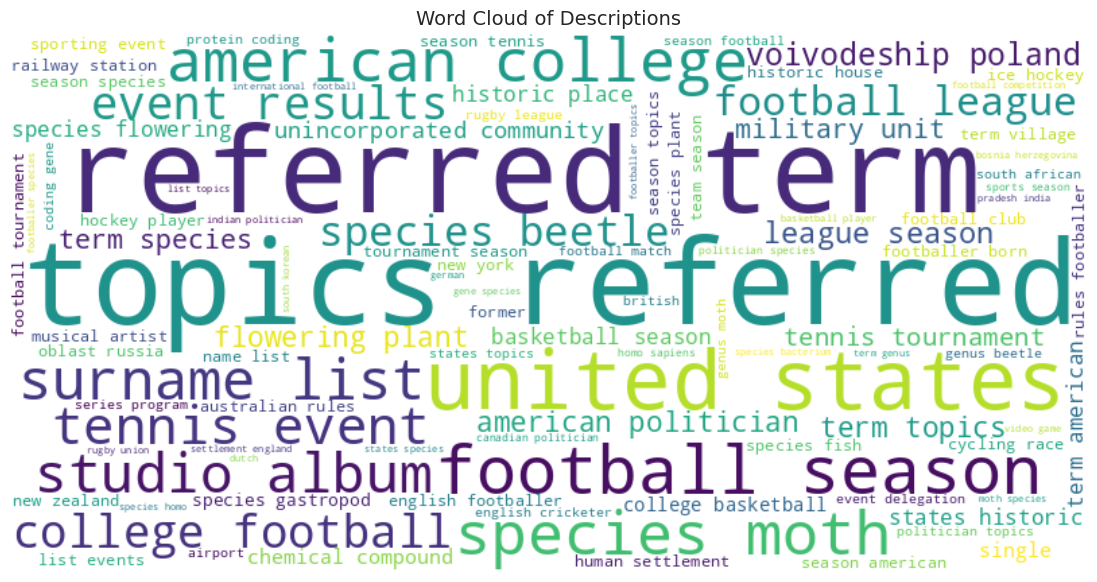

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


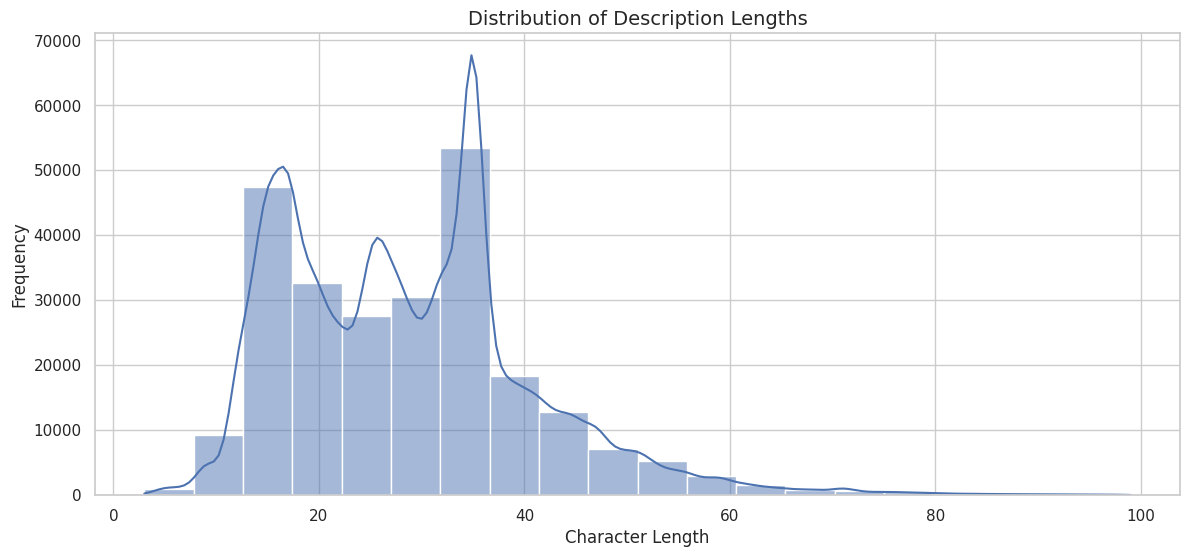

Average description length: 28.7 characters


In [8]:
# Analysis for description field
if 'description' in df.columns:
    
    # Handle descriptions as strings or lists/dicts
    descriptions = []
    for desc in df['description'].dropna():
        if isinstance(desc, str):
            descriptions.append(desc)
        elif isinstance(desc, list):
            descriptions.extend([d for d in desc if isinstance(d, str)])
    
    # Word frequency in descriptions
    all_descriptions = ' '.join(descriptions)
    words = re.findall(r'\b\w+\b', all_descriptions.lower())
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    desc_word_freq = Counter(filtered_words)
    
    # Display top words
    print("Most common words in descriptions:")
    for word, count in desc_word_freq.most_common(15):
        print(f"  {word}: {count}")
    
    # Word cloud for descriptions
    plt.figure(figsize=(14, 7))
    desc_cloud = WordCloud(width=800, height=400,
                         background_color='white',
                         max_words=100).generate(' '.join(filtered_words))
    plt.imshow(desc_cloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Descriptions', fontsize=14)
    plt.show()
    
    # Description length analysis
    desc_lengths = [len(d) for d in descriptions]
    plt.figure(figsize=(14, 6))
    sns.histplot(desc_lengths, bins=20, kde=True)
    plt.title('Distribution of Description Lengths', fontsize=14)
    plt.xlabel('Character Length', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()
    
    print(f"Average description length: {np.mean(desc_lengths):.1f} characters")

## Explore Abstracts

Average abstract length: 396.8 characters


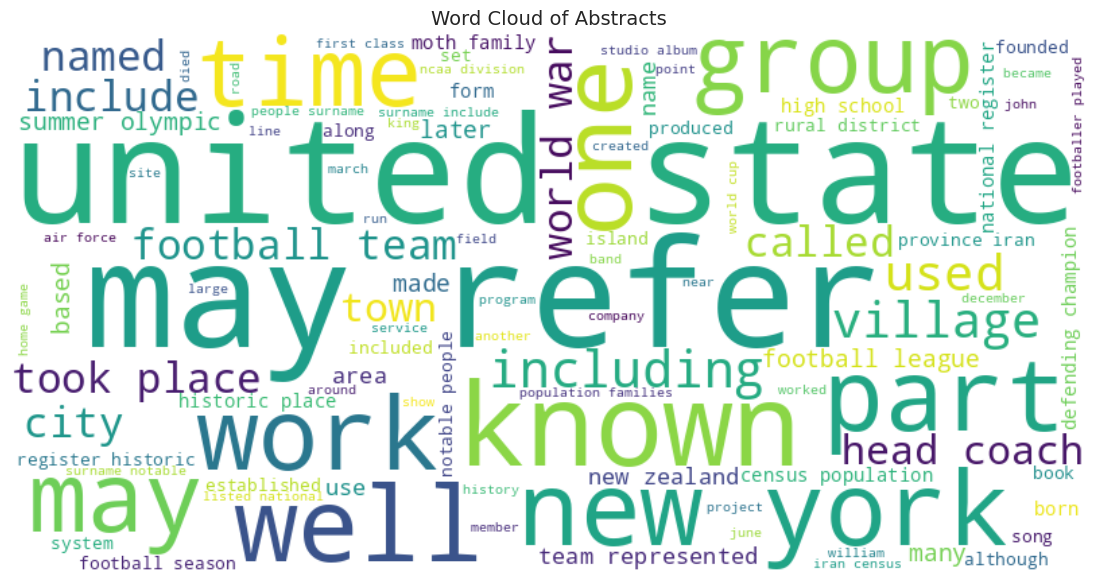

In [9]:
if 'abstract' in df.columns:
    
    # Handle abstracts as strings or lists/dicts
    abstracts = []
    for abstract in df['abstract'].dropna():
        if isinstance(abstract, str):
            abstracts.append(abstract)
        elif isinstance(abstract, list):
            abstracts.extend([a for a in abstract if isinstance(a, str)])

    abstract_lengths = [len(a) for a in abstracts]
    print(f"Average abstract length: {np.mean(abstract_lengths):.1f} characters")
    
    # Word cloud for abstracts
    if abstracts:
        all_abstracts = ' '.join(abstracts)
        words = re.findall(r'\b\w+\b', all_abstracts.lower())
        filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
        
        plt.figure(figsize=(14, 7))
        abstract_cloud = WordCloud(width=800, height=400,
                                 background_color='white',
                                 max_words=100).generate(' '.join(filtered_words))
        plt.imshow(abstract_cloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Abstracts', fontsize=14)
        plt.show()

## Explore Images

Records with images: 90607 (29.3%)
Records without images: 218902 (70.7%)


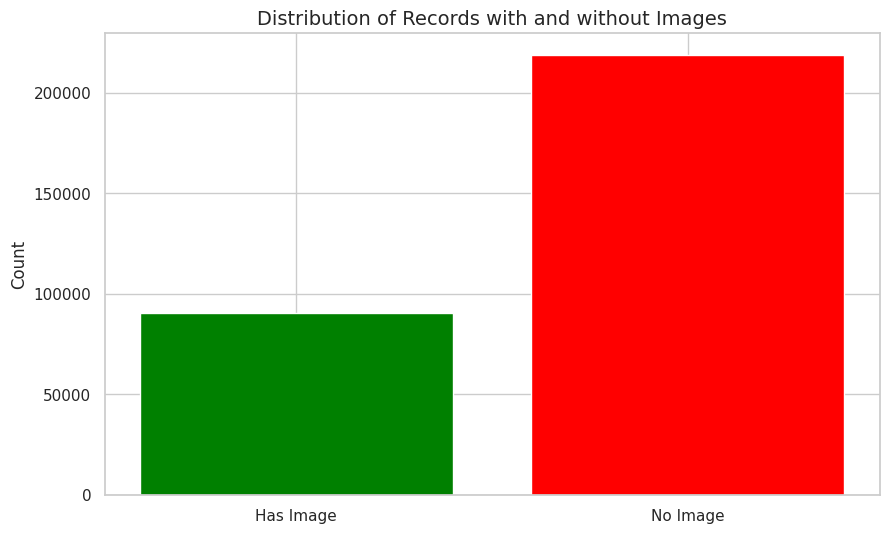

In [10]:
if 'image' in df.columns:
    
    # Count number of records with images
    image_present = df['image'].notna()
    image_count = image_present.sum()
    no_image_count = (~image_present).sum()
    
    print(f"Records with images: {image_count} ({image_count/len(df)*100:.1f}%)")
    print(f"Records without images: {no_image_count} ({no_image_count/len(df)*100:.1f}%)")
    
    # Visualize image presence distribution
    plt.figure(figsize=(10, 6))
    plt.bar(['Has Image', 'No Image'], [image_count, no_image_count], color=['green', 'red'])
    plt.title('Distribution of Records with and without Images', fontsize=14)
    plt.ylabel('Count', fontsize=12)
    plt.show()


# Images to text
Use image to text models to see if more relevant information be extracted like Keywords for tags or captions to be used in prompts to generate similar images.

In [11]:
print('image' in df.columns)

True


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309509 entries, 0 to 309508
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   name                 309509 non-null  object
 1   identifier           309509 non-null  int64 
 2   version              309509 non-null  object
 3   event                309509 non-null  object
 4   url                  309509 non-null  object
 5   date_created         300 non-null     object
 6   date_modified        309509 non-null  object
 7   is_part_of           309509 non-null  object
 8   in_language          309509 non-null  object
 9   license              309509 non-null  object
 10  description          252651 non-null  object
 11  sections             309447 non-null  object
 12  abstract             309004 non-null  object
 13  main_entity          309128 non-null  object
 14  additional_entities  309133 non-null  object
 15  infoboxes            212068 non-nu

In [13]:
# what is in the image object
df['image'][5]

{'content_url': 'https://upload.wikimedia.org/wikipedia/commons/c/ca/Juan_Benet_headshot.jpg',
 'width': 2448,
 'height': 2450}

In [14]:
# Filter only rows that contain images
image_rows = df[df['image'].notnull()].copy()

# Extract the metadata from the 'image' column
image_metadata = pd.json_normalize(image_rows['image'])

# Add back other useful columns from the main DataFrame
image_metadata['wikipedia_url'] = image_rows['url'].values
image_metadata['page_name'] = image_rows['name'].values

image_metadata.head()

,content_url,width,height,wikipedia_url,page_name
0,https://upload.wikimedia.org/wikipedia/commons...,2448,2450,https://en.wikipedia.org/wiki/Juan_Benet_(comp...,Juan Benet (computer scientist)
1,https://upload.wikimedia.org/wikipedia/commons...,685,768,https://en.wikipedia.org/wiki/1906_Minnesota_S...,1906 Minnesota Senate election
2,https://upload.wikimedia.org/wikipedia/commons...,1125,895,https://en.wikipedia.org/wiki/1906_Mississippi...,1906 Mississippi hurricane
3,https://upload.wikimedia.org/wikipedia/commons...,250,250,https://en.wikipedia.org/wiki/1214_Richilde,1214 Richilde
4,https://upload.wikimedia.org/wikipedia/commons...,800,651,https://en.wikipedia.org/wiki/130th_Engineer_B...,130th Engineer Battalion


In [15]:
# Extract image name from the URL
image_metadata['filename'] = image_metadata['content_url'].apply(lambda url: url.split('/')[-1])

# Add resolution as string and tuple
image_metadata['resolution'] = image_metadata['width'].astype(str) + 'x' + image_metadata['height'].astype(str)
image_metadata['resolution_tuple'] = list(zip(image_metadata['width'], image_metadata['height']))
image_metadata.head()

,content_url,width,height,wikipedia_url,page_name,filename,resolution,resolution_tuple
0,https://upload.wikimedia.org/wikipedia/commons...,2448,2450,https://en.wikipedia.org/wiki/Juan_Benet_(comp...,Juan Benet (computer scientist),Juan_Benet_headshot.jpg,2448x2450,"(2448, 2450)"
1,https://upload.wikimedia.org/wikipedia/commons...,685,768,https://en.wikipedia.org/wiki/1906_Minnesota_S...,1906 Minnesota Senate election,MNSen1906.svg,685x768,"(685, 768)"
2,https://upload.wikimedia.org/wikipedia/commons...,1125,895,https://en.wikipedia.org/wiki/1906_Mississippi...,1906 Mississippi hurricane,1906_Pensacola_Hurricane_Damage.PNG,1125x895,"(1125, 895)"
3,https://upload.wikimedia.org/wikipedia/commons...,250,250,https://en.wikipedia.org/wiki/1214_Richilde,1214 Richilde,001214-asteroid_shape_model_%281214%29_Richild...,250x250,"(250, 250)"
4,https://upload.wikimedia.org/wikipedia/commons...,800,651,https://en.wikipedia.org/wiki/130th_Engineer_B...,130th Engineer Battalion,130th-engineer-battalion-distinctive-unit-insi...,800x651,"(800, 651)"


In [16]:
# Placeholder column for predicted keywords
image_metadata['keywords'] = None  # or np.nan if preferred


```
    content_url         → direct link to the image
    width, height       → dimensions
    resolution          → "1920x1080" style
    resolution_tuple    → (1920, 1080)
    wikipedia_url       → page the image is used in
    page_name           → name of the wiki page
    filename            → just the filename.jpg
    keywords            → [to be filled later]
```

**IF SWITCHING TO GPU. Rerun all in NEW SESSION**

In [17]:
import torch
import requests
from PIL import Image
from torchvision import transforms
from io import BytesIO
import matplotlib.image as mpimg
from PIL import UnidentifiedImageError

In [18]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

CUDA available: False
Device: cpu


## Find keywords
Implement OpenClip with a set of candidate labels and CLIP ranks them based on the image.

In [19]:
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is incompa

In [20]:
import open_clip

### Load OpenCLIP

In [21]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    print("Using TPU")
except ImportError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using {device}")

model.to(device)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using cpu


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [22]:
# Define a Zero-Shot Classifier Function
def classify_image_clip(image_url, labels):
    try:
        headers = {
            "User-Agent": "Mozilla/5.0 (compatible; KaggleNotebook/1.0; +https://www.kaggle.com/)"
        }
        response = requests.get(image_url, headers=headers, timeout=10)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert('RGB')
        image_input = preprocess(image).unsqueeze(0).to(device)

        text_inputs = tokenizer(labels).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_inputs)

            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            similarity = (image_features @ text_features.T).squeeze(0)
            top_probs = similarity.softmax(dim=0)

        top_indices = top_probs.topk(3).indices
        return [labels[i] for i in top_indices.cpu().numpy()]
    except Exception as e:
        return [f"error: {str(e)}"]


In [23]:
candidate_labels = [
    'person', 'text', 'building', 'map', 'document',
    'animal', 'logo', 'book', 'plant', 'flag',
    'computer', 'city', 'space', 'vehicle', 'painting',
    'war', 'old', 'new', 'happy', 'sad', 'history', 'science', 'math',
    'Europe', 'Asia', 'Africa', 'Anatarctica', 'North America', 'South America',
    'Oceania', 'law', 'political', 'ambiguous', 'religious', 'secular'
]

# Test on 100 images max
sampled_df = image_metadata.head(100).copy()

tqdm.pandas()
sampled_df['keywords'] = sampled_df['content_url'].progress_apply(lambda url: classify_image_clip(url, candidate_labels))


100%|██████████| 100/100 [02:35<00:00,  1.55s/it]


In [24]:
sampled_df['keywords']

0                               [happy, sad, political]
1     [error: cannot identify image file <_io.BytesI...
2                                      [old, city, sad]
3                                       [new, map, old]
4                                      [logo, old, new]
                            ...                        
95                            [map, new, North America]
96                              [animal, sad, painting]
97                                     [Asia, old, new]
98                                     [flag, new, map]
99    [error: cannot identify image file <_io.BytesI...
Name: keywords, Length: 100, dtype: object

In [25]:
# Drop rows where keywords is an error
def is_valid_keyword_list(keywords):
    return isinstance(keywords, list) and all('error:' not in kw for kw in keywords)

clean_df = sampled_df[sampled_df['keywords'].apply(is_valid_keyword_list)].reset_index(drop=True)

In [26]:
# Flatten keyword lists into a single list
all_keywords = [kw for kws in clean_df['keywords'] for kw in kws]

# Count frequency
keyword_counts = Counter(all_keywords)
top_keywords = keyword_counts.most_common(10)

# Convert to DataFrame for plotting
keyword_df = pd.DataFrame(top_keywords, columns=["Keyword", "Count"])

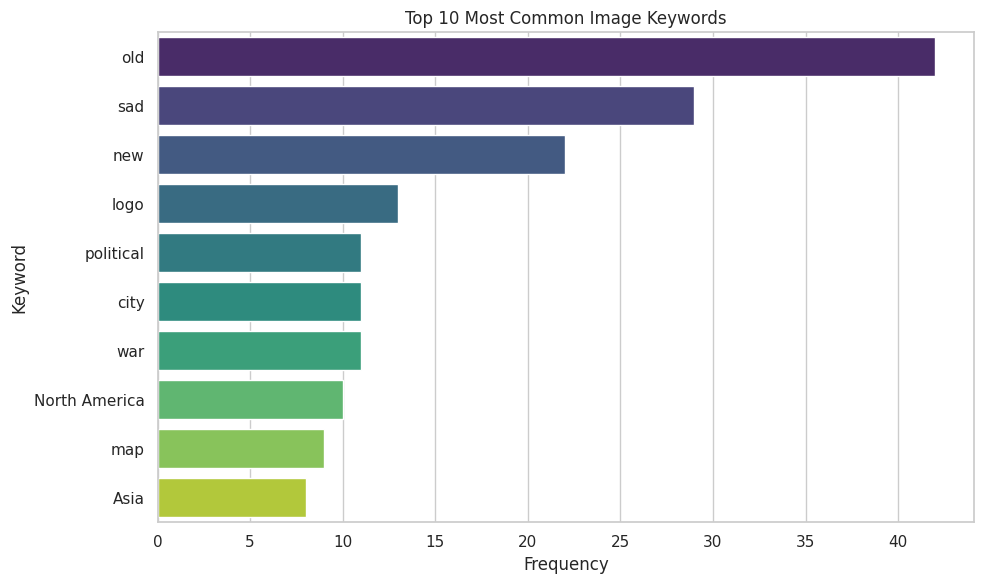

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=keyword_df, x="Count", y="Keyword", palette="viridis")
plt.title("Top 10 Most Common Image Keywords")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

In [28]:
clean_df.to_csv("image_metadata_with_keywords.csv", index=False)

## Generate Captions


In [29]:
!pip install -q transformers accelerate timm

In [30]:
from transformers import BlipProcessor, BlipForConditionalGeneration

2025-05-03 01:01:27.696454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746234087.942013      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746234088.012318      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Load BLIP Model

In [31]:
# Load BLIP model and processor
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [32]:
def generate_caption_blip(image_url):
    try:
        headers = {
            "User-Agent": "Mozilla/5.0 (compatible; KaggleNotebook/1.0; +https://www.kaggle.com/)"
        }
        response = requests.get(image_url, headers=headers, timeout=10)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert('RGB')
        inputs = processor(images=image, return_tensors="pt").to(device)

        out = model.generate(**inputs)
        caption = processor.decode(out[0], skip_special_tokens=True)
        return caption
    except Exception as e:
        return f"error: {str(e)}"

In [33]:
clean_df['caption'] = clean_df['content_url'].progress_apply(generate_caption_blip)


100%|██████████| 72/72 [03:32<00:00,  2.95s/it]


In [34]:
clean_df['caption'].head()

0                 a man with a beard and a hoodie
1             a black and white photo of a harbor
2             a rock with a white substance on it
3                 the logo for skill and strength
4    a group of men in uniform posing for a photo
Name: caption, dtype: object

In [35]:
# Ensure we have only valid rows with captions
valid_df = clean_df[clean_df['caption'].apply(lambda x: not x.startswith("error:"))]

In [36]:
valid_df.to_csv("image_metadata_with_keywords_and_captions.csv", index=False)

In [37]:
def safe_load_image(url):
    try:
        # Check if the content is an image
        headers = {
            "User-Agent": "Mozilla/5.0 (compatible; KaggleNotebook/1.0; +https://www.kaggle.com/)"
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        # Check content type for image
        if 'image' in response.headers['Content-Type']:
            img = Image.open(BytesIO(response.content))
            return img
        else:
            return None  # Not an image
    except (requests.exceptions.RequestException, UnidentifiedImageError) as e:
        print(f"Error loading image from {url}: {e}")
        return None

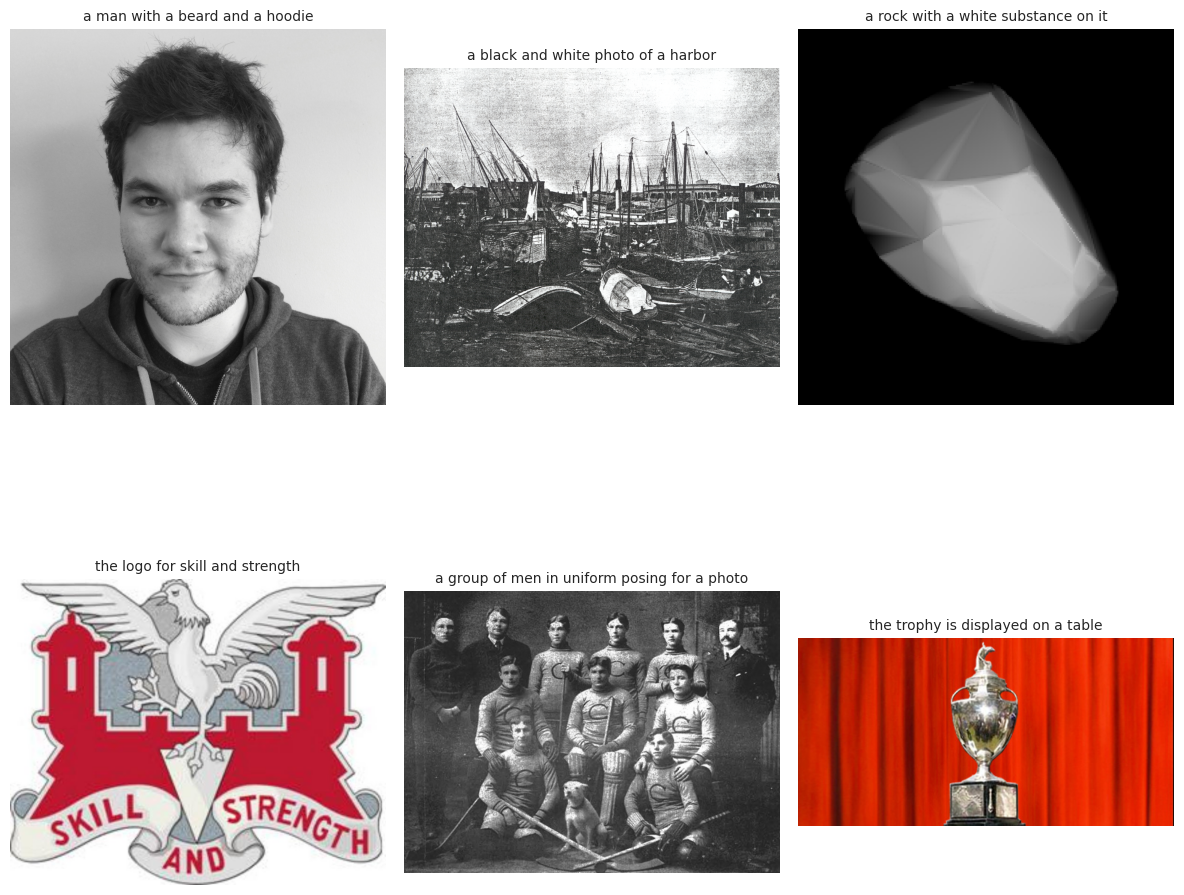

In [38]:
# Number of images to display
num_images = 6

# Plot setup
plt.figure(figsize=(12, 12))

# Loop through the DataFrame and display the first few images and their captions
for i in range(num_images):
    url = valid_df.iloc[i]['content_url']
    caption = valid_df.iloc[i]['caption']
    
    # Safely load the image
    img = safe_load_image(url)
    
    if img is not None:
        # Plot image
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")  # Hide axis
        plt.title(caption, fontsize=10)
    else:# Create a combined list of common keywords
        print(f"Skipping invalid image {url}")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


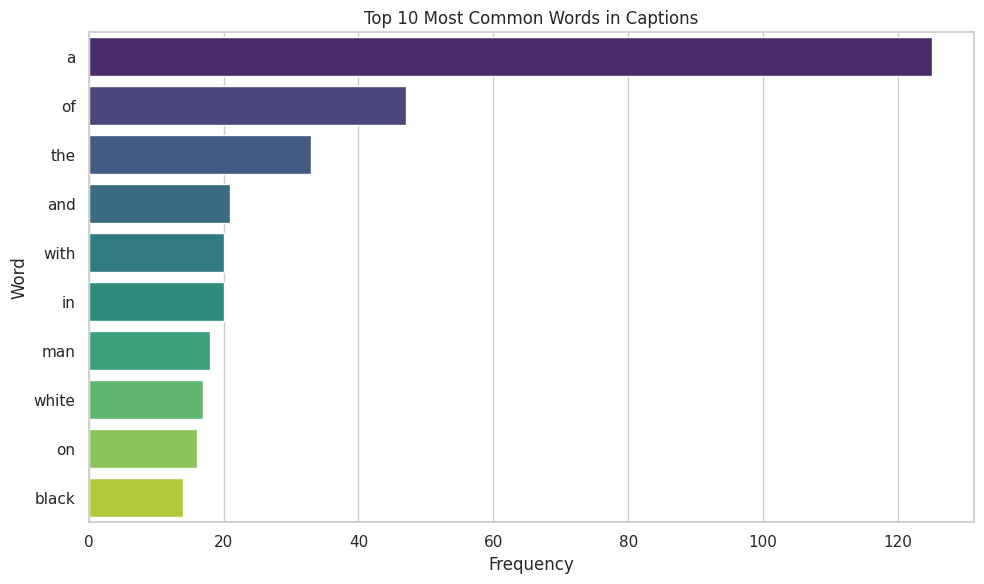

In [39]:
# Extract simple keywords from captions (just words)
captions_words = [word for caption in valid_df['caption'] for word in caption.lower().split()]

# Count frequency of words
caption_word_counts = Counter(captions_words)
top_caption_words = caption_word_counts.most_common(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=[item[1] for item in top_caption_words], y=[item[0] for item in top_caption_words], palette="viridis")
plt.title("Top 10 Most Common Words in Captions")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## Compare CLIP & BLIP
### Find overlap of captions and keywords.

In [40]:
# Create a new DataFrame with the keywords from both models
comparison_df = valid_df[['content_url', 'keywords', 'caption']].copy()

In [41]:
# Extract words from CLIP keywords and BLIP captions
def extract_words(text_list):
    words = []
    for item in text_list:
        words.extend(item.lower().split())  # Convert to lowercase and split into words
    return set(words)

# Apply the word extraction for both CLIP keywords and BLIP captions
comparison_df['clip_words'] = comparison_df['keywords'].apply(extract_words)
comparison_df['blip_words'] = comparison_df['caption'].apply(extract_words)

In [42]:
# Calculate the intersection of keywords from CLIP and BLIP for each image
comparison_df['overlap'] = comparison_df.apply(lambda row: len(row['clip_words'].intersection(row['blip_words'])), axis=1)

In [43]:
average_overlap = comparison_df['overlap'].mean()
print(f"Average overlap of keywords: {average_overlap:.2f}")

Average overlap of keywords: 0.00


In [44]:
# Create a combined list of common keywords
common_keywords = []
for _, row in comparison_df.iterrows():
    common_keywords.extend(list(row['clip_words'].intersection(row['blip_words'])))

top_common_keywords = Counter(common_keywords).most_common(10)
print("Top 10 common keywords:", top_common_keywords)

Top 10 common keywords: []


No overlap is definitely a bit of a plot twist — but it's also super interesting! It could means CLIP and BLIP are probably looking at very different aspects of the images. 

In [45]:
# TODO: 
# Compare description and generated captions
# Run CLIP on whole dataset
# Run BLIP on whole dataset
# Derive common words from Abstracts then use them as keyword candidates to check for overlaps in generated captions 
# # and descriptions.